In [1]:
import matplotlib.pyplot as plt
import networkx as nx
capacity1 = 3
capacity2 = 5
target=4
jug1 = 0
jug2 = 0
visited = set()
path = []

In [2]:
def dfs(jug1, jug2):
  if(jug1, jug2) in visited:
    return False
  visited.add((jug1, jug2))
  path.append((jug1, jug2))
  if jug1 == target or jug2 == target:
    return True
  if jug1 != capacity1:
    if dfs(capacity1, jug2):
      return True
  if jug2 != capacity2:
    if dfs(jug1, capacity2):
      return True
  if jug1 != 0:
    if dfs(0,jug2):
      return True
  if jug2 != 0:
    if dfs(jug1, 0):
      return True
  if jug1 > 0 and jug2 < capacity2:
    transfer = min(jug1, capacity2 - jug2)
    if dfs(jug1 - transfer, jug2 + transfer):
      return True
  if jug2 > 0 and jug1 < capacity1:
    transfer = min(jug2, capacity1 - jug1)
    if dfs(jug1 + transfer, jug2 - transfer):
      return True
  path.pop()
  return False
solution_found = dfs(jug1, jug2)
if solution_found:
  print("Solution found!")
  for step in path:
    print(step)
else:
  print("No solution found")


Solution found!
(0, 0)
(3, 0)
(3, 5)
(0, 5)
(3, 2)
(0, 2)
(2, 0)
(2, 5)
(3, 4)


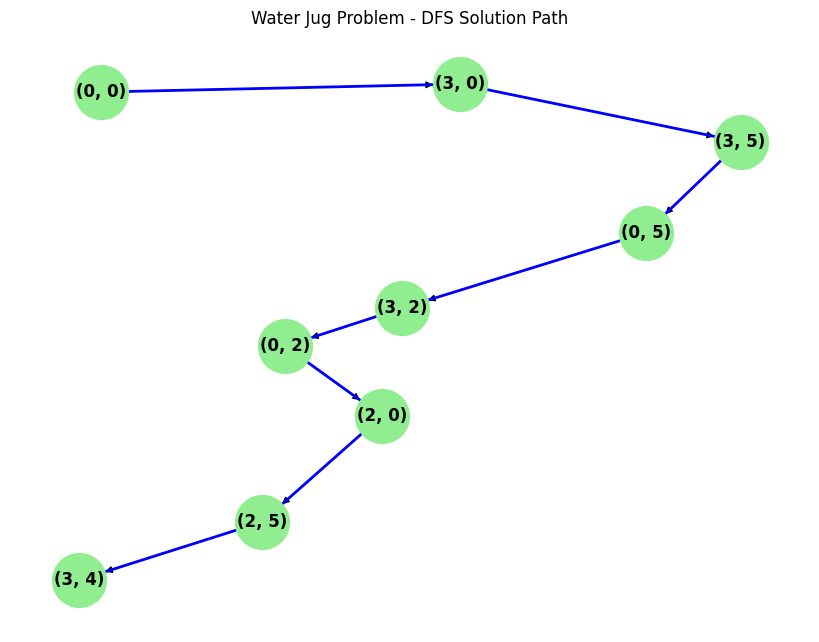

In [3]:
def visualize_dfs_solution(path):
    G = nx.DiGraph()
    for i in range(len(path) - 1):
      G.add_edge(path[i], path[i + 1])
    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1500, font_size=12, font_weight='bold')
    nx.draw_networkx_edges(G, pos, edgelist=list(G.edges()), edge_color='blue', width=2)
    plt.title("Water Jug Problem - DFS Solution Path")
    plt.show()
if solution_found:
  visualize_dfs_solution(path)

